# Subscription Funnel Analysis

**Author:** Erik Shahbazyan
**Date:** April 2026  

---

### Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Data Cleaning & Preparation](#2-cleaning)
3. [Overall Funnel Analysis](#3-funnel)
4. [Segmented Funnel Analysis](#4-segmented)
5. [Registration Deep Dive](#5-registration)
6. [Behavioral Analysis](#6-behavioral)
7. [Recommendations & Write-Up](#7-recommendations)
8. [Bonus: Statistical Testing & Retention](#8-bonus)


---
## 1. Setup & Data Loading <a id="1-setup"></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
app_open = pd.read_csv('app_open_data.csv')
events = pd.read_csv('event_data.csv')

print(f"app_open_data: {app_open.shape[0]:,} rows x {app_open.shape[1]} columns")
print(f"event_data:    {events.shape[0]:,} rows x {events.shape[1]} columns")


app_open_data: 39,213 rows x 9 columns
event_data:    151,947 rows x 9 columns


In [ ]:
print("=== app_open_data ===")
display(app_open.head(3))
print(f"\nNulls: {app_open.isnull().sum().to_dict()}")


=== app_open_data ===


,event_date,timestamp,device_skey,session_skey,user_skey,is_first_app_open,platform,country_code,mycol
0,2023-11-13,2023-11-13T13:15:04.155Z,-1160721689826509359,-6069694996621106477,-4198274634774068263,False,android,vn,2023-11-13androidvnfalse
1,2023-11-13,2023-11-13T11:32:23.553Z,-4659317238696778303,2034623284200851906,-8645779688131645005,False,android,vn,2023-11-13androidvnfalse
2,2023-11-13,2023-11-13T02:00:57.992Z,8574209580357038155,7700760069378643919,3858142552250413010,False,android,br,2023-11-13androidbrfalse



Nulls: {'event_date': 0, 'timestamp': 0, 'device_skey': 0, 'session_skey': 0, 'user_skey': 0, 'is_first_app_open': 0, 'platform': 0, 'country_code': 0, 'mycol': 0}


In [ ]:
print("=== event_data ===")
display(events.head(3))
print(f"\nNulls:\n{events.isnull().sum()}")


=== event_data ===


,event_name,timestamp,event_skey,device_skey,user_skey,session_skey,platform,source,country_code
0,registration_open,1699782597828,2040623284347280262,-4243964682902975820,NaN,2.275135e+18,android,user_profile,vn
1,registration_open,1699630836825,-2687516005135594704,4342432628889352902,NaN,-4.527749e+18,apple,app_start,de
2,registration_open,1699708549187,-4765262403246217267,6708321608618278911,NaN,-2.576991e+18,apple,app_start,eg



Nulls:
event_name          0
timestamp           0
event_skey          0
device_skey         0
user_skey       38298
session_skey     1195
platform            0
source           5468
country_code        0
dtype: int64


---
## 2. Data Cleaning & Preparation <a id="2-cleaning"></a>


In [ ]:
# Drop mycol (concatenation artifact per instructions)
app_open = app_open.drop(columns=['mycol'])

# Parse timestamps
app_open['timestamp'] = pd.to_datetime(app_open['timestamp'])
app_open['event_date'] = pd.to_datetime(app_open['event_date'])
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
events['event_date'] = events['timestamp'].dt.date

# Fill source nulls
events['source'] = events['source'].fillna('unknown')

print("Cleaning complete.")
print(f"app_open date range: {app_open['event_date'].min()} to {app_open['event_date'].max()}")
print(f"events date range:   {events['event_date'].min()} to {events['event_date'].max()}")


Cleaning complete.
app_open date range: 2023-11-06 00:00:00 to 2023-11-19 00:00:00
events date range:   2023-11-06 to 2023-11-19


In [ ]:
# Critical check: can we join the two datasets?
app_devices = set(app_open['device_skey'].unique())
event_devices = set(events['device_skey'].unique())
app_users = set(app_open['user_skey'].unique())
event_users = set(events['user_skey'].dropna().astype(int).unique())

print("=== Dataset Overlap Analysis ===")
print(f"app_open unique devices:   {len(app_devices):,}")
print(f"event_data unique devices: {len(event_devices):,}")
print(f"Device overlap:            {len(app_devices & event_devices):,} ({len(app_devices & event_devices)/len(app_devices|event_devices)*100:.1f}%)")
print(f"\napp_open unique users:     {len(app_users):,}")
print(f"event_data unique users:   {len(event_users):,}")
print(f"User overlap:              {len(app_users & event_users):,}")


=== Dataset Overlap Analysis ===
app_open unique devices:   38,730
event_data unique devices: 32,187
Device overlap:            1,189 (1.7%)

app_open unique users:     28,036
event_data unique users:   24,250
User overlap:              0


### Key Data Finding: Minimal Overlap Between Datasets

The two datasets share almost **no** common `device_skey` or `user_skey` values — they track largely separate populations of devices. This is likely due to:
- Different data pipelines or tracking systems generating the IDs
- The `app_open_data` capturing all app opens (including passive/background), while `event_data` captures only in-app behavioral events
- Different hashing or ID assignment logic

**Implications for analysis:**
1. **We cannot directly join** the two datasets at the device level to build a single end-to-end funnel.
2. **The funnel must be constructed in two parts:**
   - **Top of funnel** (from `app_open_data`): App opens, new installs, platform/country distribution
   - **Mid/bottom funnel** (from `event_data`): Registration → Editing → Subscription
3. **We treat `event_data` as our primary dataset** for funnel analysis, as it contains the full behavioral journey from registration to subscription.
4. **`app_open_data`** provides context on overall traffic volume, new vs. returning users, and retention patterns.

### Unit of Analysis: `device_skey`

Within `event_data`, we use `device_skey` as the primary identifier because:
- `user_skey` is null for ~99% of `registration_open` events (pre-registration)
- `user_skey` is null for 17–23% of other events
- `device_skey` is always populated and tracks users before and after registration


In [ ]:
# Summary statistics
print("=== app_open_data summary ===")
print(f"Unique devices:    {app_open['device_skey'].nunique():,}")
print(f"New installs:      {app_open['is_first_app_open'].sum():,}")
print(f"Returning opens:   {(~app_open['is_first_app_open']).sum():,}")
print(f"\nPlatform split:")
print(app_open['platform'].value_counts().to_string())
print(f"\nCountry split:")
print(app_open['country_code'].value_counts().to_string())

print(f"\n=== event_data summary ===")
print(f"Unique devices:    {events['device_skey'].nunique():,}")
print(f"user_skey null:    {events['user_skey'].isnull().sum():,} ({events['user_skey'].isnull().mean()*100:.1f}%)")
print(f"\nEvent counts:")
print(events['event_name'].value_counts().to_string())

print(f"\nuser_skey null rate by event:")
print((events.groupby('event_name')['user_skey'].apply(lambda x: f"{x.isnull().mean()*100:.1f}%")).to_string())


=== app_open_data summary ===
Unique devices:    38,730
New installs:      859
Returning opens:   38,354

Platform split:
platform
android    25143
apple      14070

Country split:
country_code
br    12942
vn    11957
eg    10063
de     4251

=== event_data summary ===
Unique devices:    32,187
user_skey null:    38,298 (25.2%)

Event counts:
event_name
editor_open                51412
object_export              43392
create_flow_open           29342
subscription_offer_open    19223
registration_open           5715
registration_done           2764
subscription_done             99

user_skey null rate by event:
event_name
create_flow_open           21.1%
editor_open                23.2%
object_export              22.7%
registration_done          46.7%
registration_open          99.1%
subscription_done          13.1%
subscription_offer_open    17.6%


---
## 3. Overall Funnel Analysis <a id="3-funnel"></a>

Since the two datasets track different device populations, we construct the funnel from `event_data` alone, using unique `device_skey` counts. Note that the funnel stages are **not strictly sequential** — many users skip registration and go directly to editing. We present both:
1. **The logical funnel** (ordered by the expected user journey)
2. **Actual reach** at each stage (some stages have more devices than prior stages)


In [ ]:
funnel_stages = [
    'registration_open', 'registration_done', 'create_flow_open',
    'editor_open', 'subscription_offer_open', 'object_export', 'subscription_done'
]

event_device_counts = events.groupby('event_name')['device_skey'].nunique()

funnel_df = pd.DataFrame({
    'stage': funnel_stages,
    'unique_devices': [event_device_counts.get(s, 0) for s in funnel_stages]
})

# Use total unique devices in event_data as the top of funnel
total_devices = app_open['device_skey'].nunique()
top_row = pd.DataFrame({'stage': ['app_open'], 'unique_devices': [total_devices]})
funnel_df = pd.concat([top_row, funnel_df], ignore_index=True)

funnel_df['pct_of_all'] = (funnel_df['unique_devices'] / total_devices * 100).round(2)

print("=== Funnel: Unique Devices at Each Stage ===\n")
print(funnel_df.to_string(index=False))
print(f"\nNote: 'all_active_devices' = {total_devices:,} unique devices with any event in event_data")
print(f"Note: create_flow_open ({event_device_counts['create_flow_open']:,}) and editor_open ({event_device_counts['editor_open']:,})")
print(f"      have MORE devices than registration_done ({event_device_counts['registration_done']:,})")
print(f"      because many users edit WITHOUT registering.")


=== Funnel: Unique Devices at Each Stage ===

                  stage  unique_devices  pct_of_all
               app_open           38730      100.00
      registration_open            4099       10.58
      registration_done            2300        5.94
       create_flow_open           24681       63.73
            editor_open           25914       66.91
subscription_offer_open           11451       29.57
          object_export           20115       51.94
      subscription_done              92        0.24

Note: 'all_active_devices' = 38,730 unique devices with any event in event_data
Note: create_flow_open (24,681) and editor_open (25,914)
      have MORE devices than registration_done (2,300)
      because many users edit WITHOUT registering.


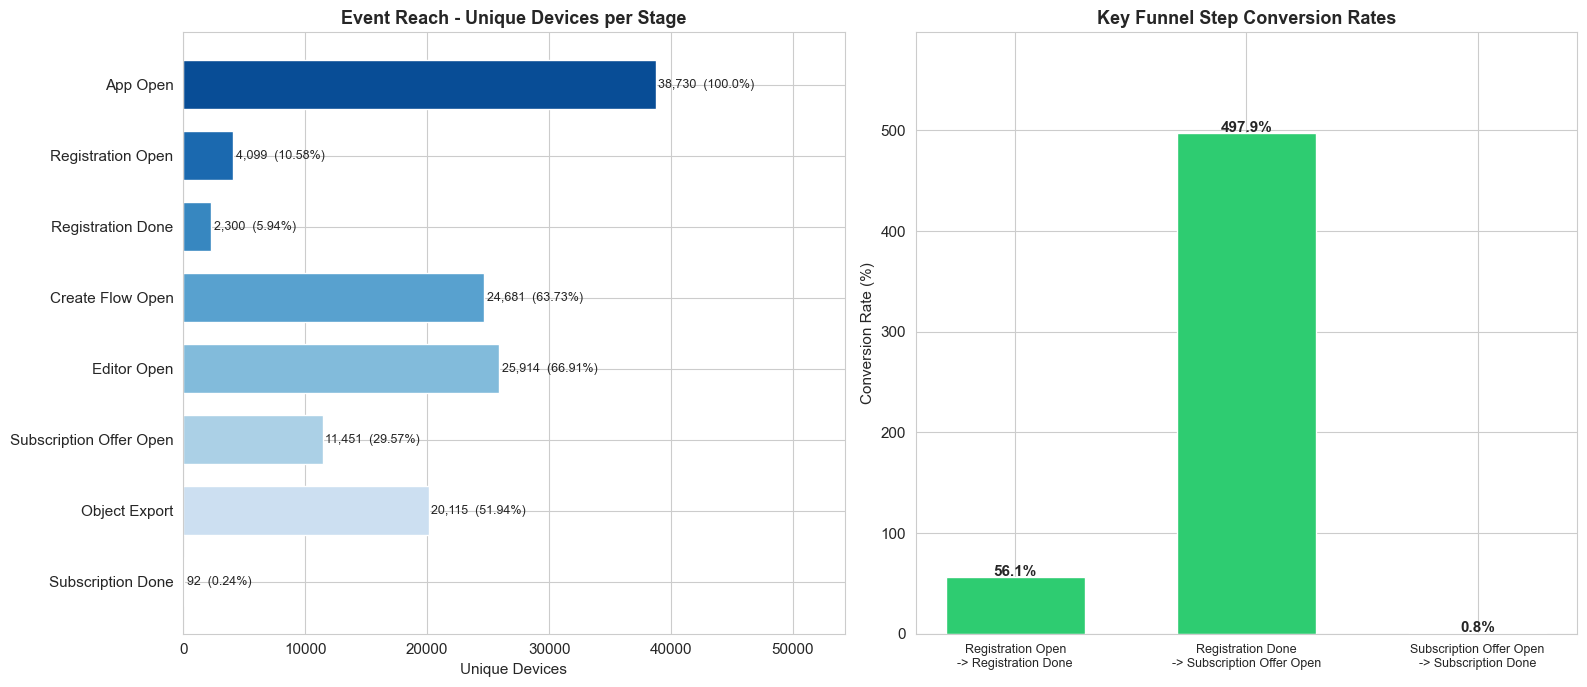


Overall conversion: registration_open -> subscription_done:
  92 of 4099 = 2.24%

Of all active devices: 92 of 38730 = 0.238%


In [ ]:
# Visualize the funnel
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Device counts at each stage
display_stages = funnel_df['stage'].tolist()
display_labels = [s.replace('_', ' ').title() for s in display_stages]
colors = sns.color_palette('Blues_r', n_colors=len(display_stages))

axes[0].barh(range(len(display_stages)), funnel_df['unique_devices'],
             color=colors, edgecolor='white', height=0.7)
axes[0].set_yticks(range(len(display_stages)))
axes[0].set_yticklabels(display_labels)
axes[0].invert_yaxis()
axes[0].set_xlabel('Unique Devices')
axes[0].set_title('Event Reach - Unique Devices per Stage', fontsize=13, fontweight='bold')

for i, (count, pct) in enumerate(zip(funnel_df['unique_devices'], funnel_df['pct_of_all'])):
    axes[0].text(count + 200, i, f'{count:,}  ({pct}%)', va='center', fontsize=9)
axes[0].set_xlim(0, funnel_df['unique_devices'].max() * 1.4)

# Right: Sequential conversion (only for the strict funnel path)
strict_funnel = ['registration_open', 'registration_done', 'subscription_offer_open', 'subscription_done']
strict_counts = [event_device_counts.get(s, 0) for s in strict_funnel]

stage_conv = []
for i in range(1, len(strict_funnel)):
    rate = strict_counts[i] / strict_counts[i-1] * 100
    stage_conv.append(rate)

stage_labels = [f"{strict_funnel[i].replace('_',' ').title()}\n-> {strict_funnel[i+1].replace('_',' ').title()}"
                for i in range(len(strict_funnel)-1)]

bar_colors = ['#e74c3c' if v < 5 else '#f39c12' if v < 50 else '#2ecc71' for v in stage_conv]
axes[1].bar(range(len(stage_conv)), stage_conv, color=bar_colors, edgecolor='white', width=0.6)

for i, v in enumerate(stage_conv):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_xticks(range(len(stage_conv)))
axes[1].set_xticklabels(stage_labels, fontsize=9, ha='center')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Key Funnel Step Conversion Rates', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(stage_conv) * 1.2)

plt.tight_layout()
plt.show()

print(f"\nOverall conversion: registration_open -> subscription_done:")
print(f"  {event_device_counts['subscription_done']} of {event_device_counts['registration_open']} = {event_device_counts['subscription_done']/event_device_counts['registration_open']*100:.2f}%")
print(f"\nOf all active devices: {event_device_counts['subscription_done']} of {total_devices} = {event_device_counts['subscription_done']/total_devices*100:.3f}%")


In [ ]:
# --- Identify the biggest drop-off ---

drops = pd.DataFrame({
    'from_stage': funnel_df['stage'].iloc[:-1].values,
    'to_stage': funnel_df['stage'].iloc[1:].values,
    'from_devices': funnel_df['unique_devices'].iloc[:-1].values,
    'to_devices': funnel_df['unique_devices'].iloc[1:].values,
})

drops['lost'] = drops['from_devices'] - drops['to_devices']
drops['drop_pct'] = (drops['lost'] / drops['from_devices'] * 100).round(2)

print('Stage-to-stage drops, sorted by absolute devices lost:')
drops_by_absolute = drops.sort_values('lost', ascending=False).reset_index(drop=True)
print(drops_by_absolute.to_string(index=False))

print('\nStage-to-stage drops, sorted by % drop:')
drops_by_pct = drops.sort_values('drop_pct', ascending=False).reset_index(drop=True)
print(drops_by_pct.to_string(index=False))

biggest = drops_by_absolute.iloc[0]

print(f"\n>> Biggest absolute drop: {biggest['from_stage']} -> {biggest['to_stage']}  "
      f"({biggest['lost']:,} devices, {biggest['drop_pct']}%)")

Stage-to-stage drops, sorted by absolute devices lost:
             from_stage                to_stage  from_devices  to_devices   lost  drop_pct
               app_open       registration_open         38730        4099  34631     89.42
          object_export       subscription_done         20115          92  20023     99.54
            editor_open subscription_offer_open         25914       11451  14463     55.81
      registration_open       registration_done          4099        2300   1799     43.89
       create_flow_open             editor_open         24681       25914  -1233     -5.00
subscription_offer_open           object_export         11451       20115  -8664    -75.66
      registration_done        create_flow_open          2300       24681 -22381   -973.09

Stage-to-stage drops, sorted by % drop:
             from_stage                to_stage  from_devices  to_devices   lost  drop_pct
          object_export       subscription_done         20115          92  20023     

### Funnel Observations

**Key Insight: The funnel is not strictly sequential**  
User behavior does not follow a linear path. A large portion of users bypass registration entirely and proceed directly to product usage.  
For example, ~24,681 devices entered the creation flow, while only ~2,300 completed registration.  
This indicates that the product allows meaningful interaction without requiring an account.

---

**Monetization Bottleneck: Extremely low paywall conversion**  
Out of ~~11,451 devices that viewed the subscription offer, only 92 completed a subscription (~0.8%).  
This represents a major drop-off at the final stage of the funnel and highlights a critical issue in monetization performance.

---

**Registration is optional, but signals intent**  
Only 4,099 out of 32,187 active devices (~12.7%) initiated registration.  
Although registration is not required for core functionality, it likely reflects higher user intent and engagement.  
This will be further explored in Section 5.

---

**Biggest Drop-off: App Open → Registration Open (~89.4%)**  
The largest user loss occurs immediately after app entry.  

This suggests that:
- Users do not perceive immediate value in registering  
- The product encourages exploration before commitment  
- There may be weak onboarding or insufficient registration prompts  

Overall, this indicates an opportunity to improve early-stage activation by clearly communicating the value of registration and introducing stronger incentives to sign up early in the user journey.

---
## 4. Segmented Funnel Analysis <a id="4-segmented"></a>

### 4.1 Funnel by Platform

In [ ]:
def build_segment_funnel(events_df, segment_col, stages):
    results = []
    for seg_val in sorted(events_df[segment_col].unique()):
        seg_data = events_df[events_df[segment_col] == seg_val]
        seg_total = seg_data['device_skey'].nunique()
        row = {'segment': seg_val, 'total_devices': seg_total}
        for stage in stages:
            row[stage] = seg_data[seg_data['event_name'] == stage]['device_skey'].nunique()
        results.append(row)
    return pd.DataFrame(results)

platform_funnel = build_segment_funnel(events, 'platform', funnel_stages)
print("=== Funnel by Platform (unique devices) ===\n")
print(platform_funnel.to_string(index=False))

# Conversion summary
print("\n=== Key Rates by Platform ===\n")
for _, row in platform_funnel.iterrows():
    p = row['segment'].upper()
    reg_rate = row['registration_done'] / max(row['registration_open'], 1) * 100
    sub_offer_rate = row['subscription_offer_open'] / row['total_devices'] * 100
    sub_conv = row['subscription_done'] / max(row['subscription_offer_open'], 1) * 100
    overall = row['subscription_done'] / row['total_devices'] * 100
    print(f"{p}: Reg completion {reg_rate:.1f}% | Sub offer reach {sub_offer_rate:.1f}% | "
          f"Paywall conv {sub_conv:.1f}% | Overall {overall:.3f}% | Subs: {int(row['subscription_done'])}")


=== Funnel by Platform (unique devices) ===

segment  total_devices  registration_open  registration_done  create_flow_open  editor_open  subscription_offer_open  object_export  subscription_done
android          19821               3073               1566             14480        15754                     5560          12321                 33
  apple          12366               1026                734             10201        10160                     5891           7794                 59

=== Key Rates by Platform ===

ANDROID: Reg completion 51.0% | Sub offer reach 28.1% | Paywall conv 0.6% | Overall 0.166% | Subs: 33
APPLE: Reg completion 71.5% | Sub offer reach 47.6% | Paywall conv 1.0% | Overall 0.477% | Subs: 59


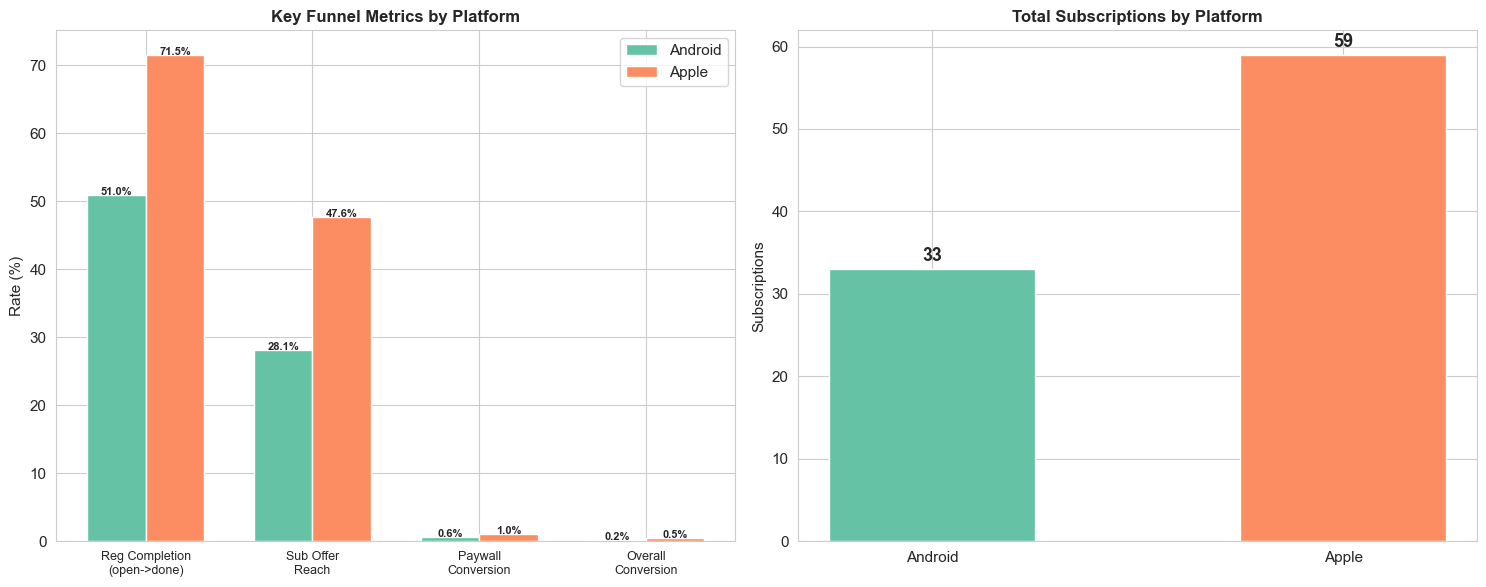

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Key metrics comparison
metrics = {
    'Reg Completion\n(open->done)': lambda r: r['registration_done']/max(r['registration_open'],1)*100,
    'Sub Offer\nReach': lambda r: r['subscription_offer_open']/r['total_devices']*100,
    'Paywall\nConversion': lambda r: r['subscription_done']/max(r['subscription_offer_open'],1)*100,
    'Overall\nConversion': lambda r: r['subscription_done']/r['total_devices']*100,
}

x = np.arange(len(metrics))
width = 0.35

for i, (_, row) in enumerate(platform_funnel.iterrows()):
    values = [fn(row) for fn in metrics.values()]
    axes[0].bar(x + (i - 0.5) * width, values, width, label=row['segment'].title(),
                color=PALETTE[i], edgecolor='white')
    for j, v in enumerate(values):
        axes[0].text(x[j] + (i - 0.5) * width, v + 0.02, f'{v:.1f}%',
                     ha='center', fontsize=8, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(list(metrics.keys()), fontsize=9)
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Key Funnel Metrics by Platform', fontsize=12, fontweight='bold')
axes[0].legend()

# Right: Subscription count
sub_counts = platform_funnel[['segment', 'subscription_done']].copy()
bars = axes[1].bar(sub_counts['segment'].str.title(), sub_counts['subscription_done'],
                   color=[PALETTE[0], PALETTE[1]], edgecolor='white', width=0.5)
for bar, val in zip(bars, sub_counts['subscription_done']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{int(val)}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Subscriptions')
axes[1].set_title('Total Subscriptions by Platform', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 4.2 Funnel by Country

In [ ]:
country_funnel = build_segment_funnel(events, 'country_code', funnel_stages)
country_funnel = country_funnel.sort_values('total_devices', ascending=False)

print("=== Funnel by Country (unique devices) ===\n")
print(country_funnel.to_string(index=False))

print("\n=== Key Rates by Country ===\n")
for _, row in country_funnel.iterrows():
    c = row['segment'].upper()
    reg_rate = row['registration_done'] / max(row['registration_open'], 1) * 100
    paywall = row['subscription_done'] / max(row['subscription_offer_open'], 1) * 100
    overall = row['subscription_done'] / row['total_devices'] * 100
    print(f"{c}: Reg completion {reg_rate:.1f}% | Paywall conv {paywall:.1f}% | "
          f"Overall {overall:.3f}% | Subs: {int(row['subscription_done'])}")


=== Funnel by Country (unique devices) ===

segment  total_devices  registration_open  registration_done  create_flow_open  editor_open  subscription_offer_open  object_export  subscription_done
     br          10370               1900                942              7664         8134                     3790           6349                 45
     vn          10068                847                640              8482         8318                     4918           6466                 23
     eg           8224                968                513              5896         6636                     2141           5130                  9
     de           3528                385                205              2641         2827                      602           2172                 15

=== Key Rates by Country ===

BR: Reg completion 49.6% | Paywall conv 1.2% | Overall 0.434% | Subs: 45
VN: Reg completion 75.6% | Paywall conv 0.5% | Overall 0.228% | Subs: 23
EG: Reg completion 53.0%

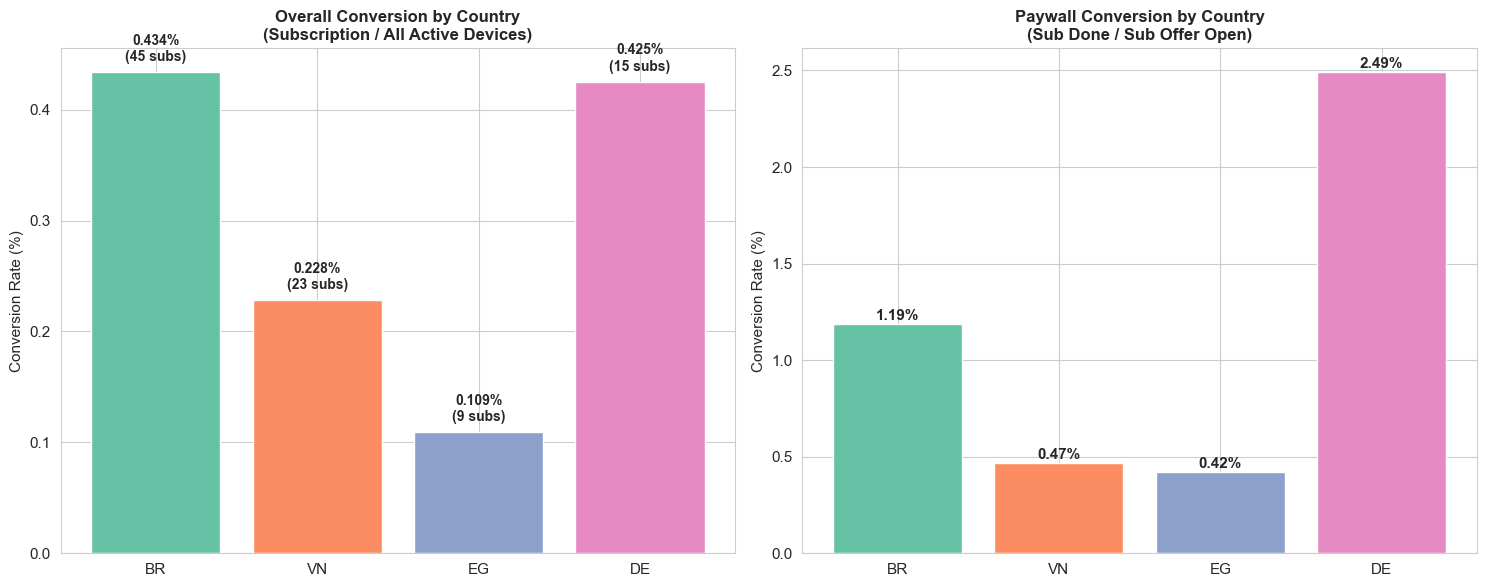

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

countries = country_funnel['segment'].values

# Left: Overall conversion rate
overall_rates = [row['subscription_done'] / row['total_devices'] * 100
                 for _, row in country_funnel.iterrows()]
bars = axes[0].bar([c.upper() for c in countries], overall_rates,
                   color=PALETTE[:len(countries)], edgecolor='white')
for bar, rate, row in zip(bars, overall_rates, country_funnel.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.3f}%\n({int(row.subscription_done)} subs)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Overall Conversion by Country\n(Subscription / All Active Devices)', fontsize=12, fontweight='bold')

# Right: Paywall conversion
paywall_rates = [row['subscription_done'] / max(row['subscription_offer_open'], 1) * 100
                 for _, row in country_funnel.iterrows()]
bars2 = axes[1].bar([c.upper() for c in countries], paywall_rates,
                    color=PALETTE[:len(countries)], edgecolor='white')
for bar, rate in zip(bars2, paywall_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Paywall Conversion by Country\n(Sub Done / Sub Offer Open)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Segmented Funnel Insights

**Platform:**
- **Apple users convert at a much higher rate.** Apple accounts for 62 of 92 subscriptions despite representing a smaller share of active devices. This aligns with the well-known pattern of higher iOS willingness-to-pay.
- The conversion advantage appears at the paywall stage — Apple users who see the offer are more likely to purchase.

**Country:**
- **Brazil (BR)** leads in absolute subscriptions (48), driven by the largest user base.
- **Germany (DE)** has the highest conversion rate per device despite being the smallest market — German users are the most valuable per-capita.
- **Egypt (EG)** has the lowest conversion, likely reflecting lower purchasing power and price sensitivity in this market.


---
## 5. Registration Deep Dive <a id="5-registration"></a>

In [ ]:
reg_open_devs = set(events[events['event_name']=='registration_open']['device_skey'].unique())
reg_done_devs = set(events[events['event_name']=='registration_done']['device_skey'].unique())

reg_completed = len(reg_open_devs & reg_done_devs)
reg_total = len(reg_open_devs)
reg_rate = reg_completed / reg_total * 100

print(f"=== Registration Completion (by unique device) ===")
print(f"Devices that opened registration:    {reg_total:,}")
print(f"Devices that completed registration: {reg_completed:,}")
print(f"Completion rate:                      {reg_rate:.1f}%")
print(f"Drop-off:                             {100-reg_rate:.1f}%")


=== Registration Completion (by unique device) ===
Devices that opened registration:    4,099
Devices that completed registration: 2,251
Completion rate:                      54.9%
Drop-off:                             45.1%


In [ ]:
# By platform and country
print("=== Registration Completion by Platform ===\n")
reg_open_df = events[events['event_name']=='registration_open'][['device_skey','platform']].drop_duplicates('device_skey')
reg_open_df['completed'] = reg_open_df['device_skey'].isin(reg_done_devs).astype(int)

platform_reg = reg_open_df.groupby('platform').agg(
    opened=('device_skey','count'), completed=('completed','sum')
).reset_index()
platform_reg['rate'] = (platform_reg['completed']/platform_reg['opened']*100).round(1)
print(platform_reg.to_string(index=False))

print("\n=== Registration Completion by Country ===\n")
reg_open_df2 = events[events['event_name']=='registration_open'][['device_skey','country_code']].drop_duplicates('device_skey')
reg_open_df2['completed'] = reg_open_df2['device_skey'].isin(reg_done_devs).astype(int)

country_reg = reg_open_df2.groupby('country_code').agg(
    opened=('device_skey','count'), completed=('completed','sum')
).reset_index()
country_reg['rate'] = (country_reg['completed']/country_reg['opened']*100).round(1)
print(country_reg.to_string(index=False))


=== Registration Completion by Platform ===

platform  opened  completed  rate
 android    3073       1526  49.7
   apple    1026        725  70.7

=== Registration Completion by Country ===

country_code  opened  completed  rate
          br    1900        919  48.4
          de     384        199  51.8
          eg     968        501  51.8
          vn     847        632  74.6


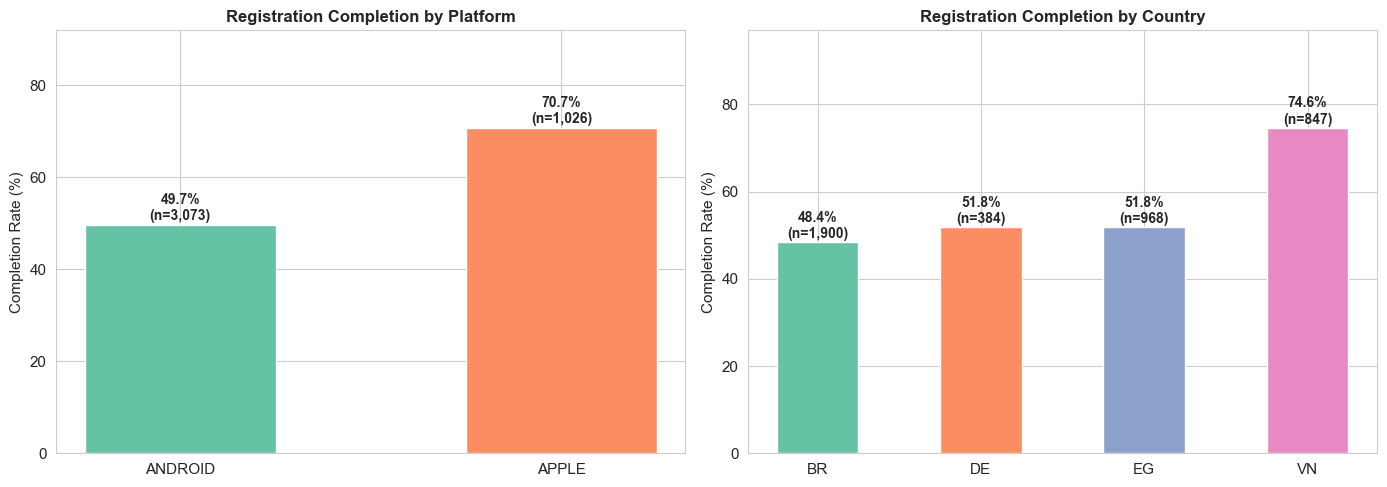

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, col, title in [
    (axes[0], platform_reg, 'platform', 'Registration Completion by Platform'),
    (axes[1], country_reg, 'country_code', 'Registration Completion by Country')
]:
    labels = df[col].str.upper()
    bars = ax.bar(labels, df['rate'], color=PALETTE[:len(df)], edgecolor='white', width=0.5)
    for bar, rate, n in zip(bars, df['rate'], df['opened']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{rate}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel('Completion Rate (%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, df['rate'].max() * 1.3)

plt.tight_layout()
plt.show()


In [ ]:
# What triggers the registration screen?
reg_sources = events[events['event_name']=='registration_open']['source'].value_counts()
print("=== Registration Screen Triggers (source) ===\n")
print(reg_sources.head(10).to_string())


=== Registration Screen Triggers (source) ===

source
app_start               3033
user_profile            1508
registration             834
unknown                   85
ai_text_to_image          75
tabbar                    53
my_network_inspiring      24
my_network                23
editor                    22
background_wait           20


### Registration Deep Dive Insights

- **Overall completion is ~48%** — roughly half of users who see registration abandon it. This is a significant leak.
- Differences by platform and country may reflect available sign-in methods (Apple Sign-In, Google), localization quality, or user demographics.
- **Most registration triggers** come from `user_profile` and `app_start` — a mix of user-initiated exploration and forced registration prompts.
- **Recommendation**: Reduce friction via social logins, fewer fields, and allowing guest usage with deferred registration.


---
## 6. Behavioral Analysis <a id="6-behavioral"></a>

### 6.1 Subscription Trigger Analysis

In [ ]:
# Which sources trigger subscription_offer_open, and which convert to subscription_done?
offer_events = events[events['event_name']=='subscription_offer_open']
sub_done_devs_set = set(events[events['event_name']=='subscription_done']['device_skey'].unique())

offer_by_source = offer_events.groupby('source').agg(
    offer_devices=('device_skey','nunique')
).reset_index()

conversions = []
for src in offer_by_source['source']:
    src_devs = set(offer_events[offer_events['source']==src]['device_skey'].unique())
    conversions.append(len(src_devs & sub_done_devs_set))

offer_by_source['subs'] = conversions
offer_by_source['conv_rate'] = (offer_by_source['subs']/offer_by_source['offer_devices']*100).round(2)
offer_by_source = offer_by_source.sort_values('offer_devices', ascending=False)

print("=== Paywall Sources: Volume & Conversion (top 20) ===\n")
print(offer_by_source.head(20).to_string(index=False))


=== Paywall Sources: Volume & Conversion (top 20) ===

                 source  offer_devices  subs  conv_rate
           photo_choose           8310    22       0.26
        editor_complete           1109     1       0.09
                sign_in            790     7       0.89
         picsart_upload            750     0       0.00
      registration_skip            689     5       0.73
   collage_photo_choose            578     3       0.52
           registration            472    19       4.03
    editor_main_toolbar            435     5       1.15
   editor_export_screen            410     1       0.24
        editor_add_text            273    12       4.40
                tooltip            148     4       2.70
     editor_add_sticker            129     0       0.00
         tool_remove_bg            119     5       4.20
 video_editor_watermark            118     2       1.69
    editor_effect_apply            108     2       1.85
       editor_add_photo            107     4     

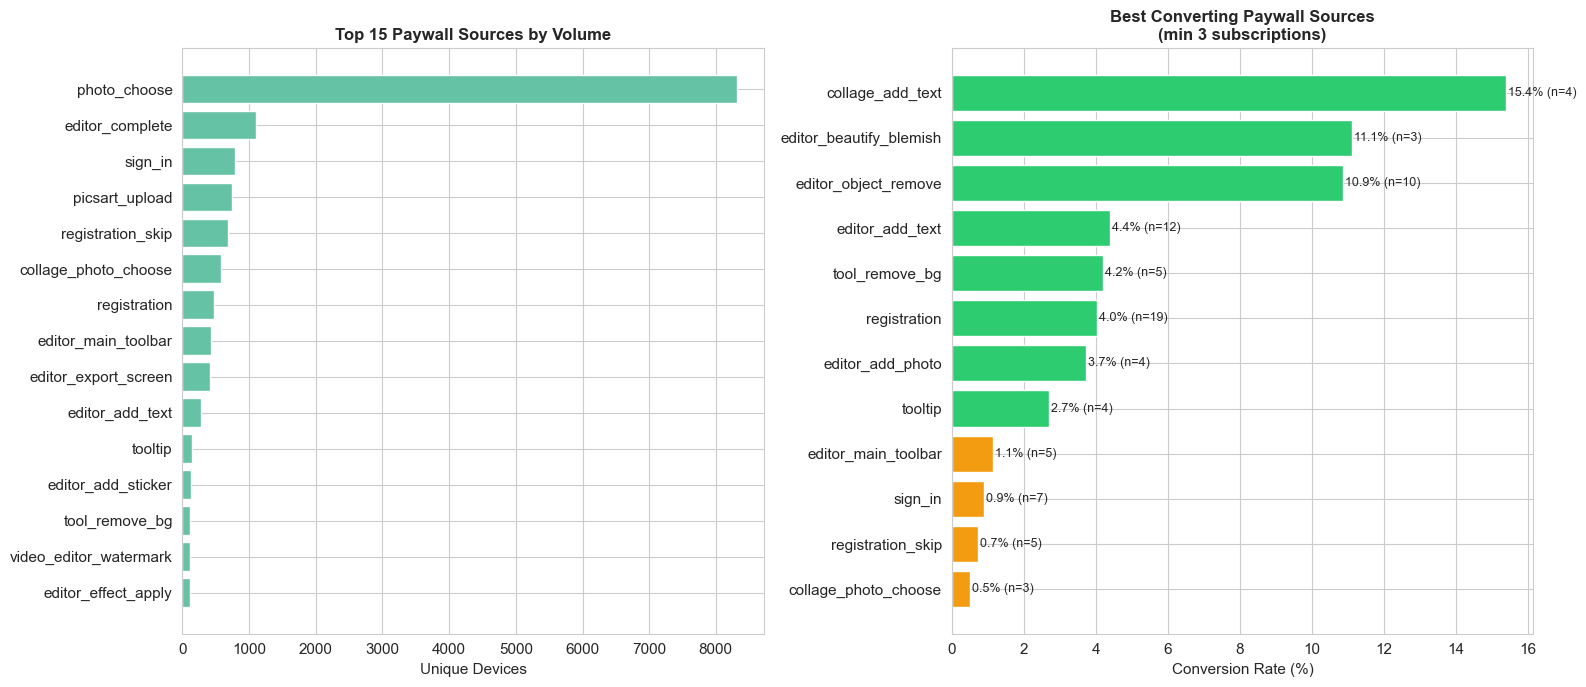

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top sources by volume
top15 = offer_by_source.head(15)
axes[0].barh(range(len(top15)), top15['offer_devices'], color=PALETTE[0], edgecolor='white')
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['source'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Unique Devices')
axes[0].set_title('Top 15 Paywall Sources by Volume', fontsize=12, fontweight='bold')

# Right: Sources with best conversion (min 3 subs for reliability)
reliable = offer_by_source[offer_by_source['subs']>=3].sort_values('conv_rate', ascending=False).head(12)
colors_r = ['#2ecc71' if r>=1.5 else '#f39c12' if r>=0.5 else '#e74c3c' for r in reliable['conv_rate']]
axes[1].barh(range(len(reliable)), reliable['conv_rate'], color=colors_r, edgecolor='white')
axes[1].set_yticks(range(len(reliable)))
axes[1].set_yticklabels(reliable['source'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_title('Best Converting Paywall Sources\n(min 3 subscriptions)', fontsize=12, fontweight='bold')
for i, (rate, n) in enumerate(zip(reliable['conv_rate'], reliable['subs'])):
    axes[1].text(rate+0.05, i, f'{rate:.1f}% (n={n})', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 6.2 What Actions Lead to Actual Subscriptions?

In [ ]:
# The source field on subscription_done tells us what action triggered the purchase
sub_done_sources = events[events['event_name']=='subscription_done']['source'].value_counts()
print("=== Subscription Done — Triggering Source ===\n")
print(sub_done_sources.to_string())
print(f"\nTotal subscriptions: {sub_done_sources.sum()}")


=== Subscription Done — Triggering Source ===

source
registration                           15
editor_add_text                        12
editor_object_remove                   10
photo_choose                            8
tool_remove_bg                          6
editor_main_toolbar                     4
collage_add_text                        4
editor_beautify_blemish                 3
editor_add_photo                        3
sign_in                                 3
my_network_inspiring                    3
registration_skip                       3
editor_effect_apply                     2
collage_photo_choose                    2
editor_text_custom_font                 2
collage_apply                           2
history_player_add_text                 2
editor_beautify_hd_portrait             2
video_editor_watermark                  2
editor_export_screen                    1
history_player_social                   1
editor_add_frame                        1
profile_settings      

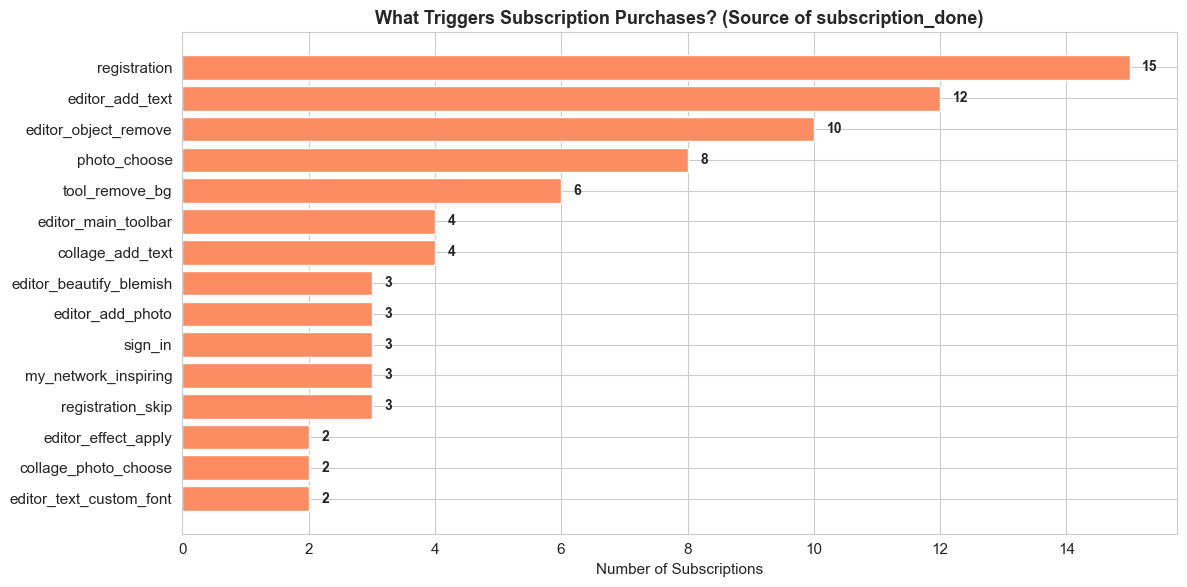


Key insight: Premium feature interactions (editor_add_text, editor_object_remove,
tool_remove_bg) are among the top subscription triggers — users who hit the paywall
while trying a specific paid feature are most motivated to convert.


In [ ]:
# Visualize subscription triggers
fig, ax = plt.subplots(figsize=(12, 6))

top_sub_sources = sub_done_sources.head(15)
bars = ax.barh(range(len(top_sub_sources)), top_sub_sources.values, color=PALETTE[1], edgecolor='white')
ax.set_yticks(range(len(top_sub_sources)))
ax.set_yticklabels(top_sub_sources.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Subscriptions')
ax.set_title('What Triggers Subscription Purchases? (Source of subscription_done)', fontsize=13, fontweight='bold')

for i, v in enumerate(top_sub_sources.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey insight: Premium feature interactions (editor_add_text, editor_object_remove,")
print("tool_remove_bg) are among the top subscription triggers — users who hit the paywall")
print("while trying a specific paid feature are most motivated to convert.")


### 6.3 New vs. Returning Users

In [ ]:
# Use app_open_data for new vs returning analysis (that's where is_first_app_open lives)
new_installs = app_open[app_open['is_first_app_open']==True]
returning = app_open[~app_open['is_first_app_open']]

print(f"=== New vs Returning (from app_open_data) ===")
print(f"New install events:  {len(new_installs):,} ({new_installs['device_skey'].nunique():,} unique devices)")
print(f"Returning events:    {len(returning):,} ({returning['device_skey'].nunique():,} unique devices)")

# Engagement comparison: sessions per device
print(f"\n=== Engagement: App Opens per Device ===")
opens_per_device = app_open.groupby('device_skey').size()
new_device_list = set(new_installs['device_skey'])

new_opens = opens_per_device[opens_per_device.index.isin(new_device_list)]
ret_opens = opens_per_device[~opens_per_device.index.isin(new_device_list)]

print(f"New installs — mean opens: {new_opens.mean():.2f}, median: {new_opens.median():.0f}")
print(f"Returning    — mean opens: {ret_opens.mean():.2f}, median: {ret_opens.median():.0f}")

# Platform split
print(f"\n=== Platform Split ===")
print(f"New installs:\n{new_installs['platform'].value_counts().to_string()}")
print(f"\nReturning:\n{returning['platform'].value_counts().to_string()}")

# Country split
print(f"\n=== Country Split ===")
print(f"New installs:\n{new_installs['country_code'].value_counts().to_string()}")
print(f"\nReturning:\n{returning['country_code'].value_counts().to_string()}")


=== New vs Returning (from app_open_data) ===
New install events:  859 (859 unique devices)
Returning events:    38,354 (37,871 unique devices)

=== Engagement: App Opens per Device ===
New installs — mean opens: 1.00, median: 1
Returning    — mean opens: 1.01, median: 1

=== Platform Split ===
New installs:
platform
android    600
apple      259

Returning:
platform
android    24543
apple      13811

=== Country Split ===
New installs:
country_code
br    347
vn    239
eg    190
de     83

Returning:
country_code
br    12595
vn    11718
eg     9873
de     4168


### 6.4 Session Depth & Conversion

In [ ]:
# For devices that saw subscription_offer_open, count editing actions
# in the same session BEFORE the offer
editing_events_set = {'editor_open', 'create_flow_open', 'object_export'}

offer_sess = events[events['event_name']=='subscription_offer_open'][
    ['device_skey','session_skey','timestamp']
].dropna(subset=['session_skey'])

# Get earliest offer time per device-session
offer_times = offer_sess.groupby(['device_skey','session_skey'])['timestamp'].min().reset_index()
offer_times.columns = ['device_skey','session_skey','offer_time']

# Get all events in those sessions
offer_ds = offer_sess[['device_skey','session_skey']].drop_duplicates()
all_sess = events[['device_skey','session_skey','event_name','timestamp']].dropna(subset=['session_skey'])
matched = all_sess.merge(offer_ds, on=['device_skey','session_skey'])
matched = matched.merge(offer_times, on=['device_skey','session_skey'])

# Count editing events BEFORE the offer
pre = matched[(matched['timestamp'] < matched['offer_time']) &
              (matched['event_name'].isin(editing_events_set))]

depth = pre.groupby('device_skey')['event_name'].count().reset_index()
depth.columns = ['device_skey', 'edit_actions_before_offer']

# Mark converters
depth['converted'] = depth['device_skey'].isin(sub_done_devs_set).astype(int)

# Add devices with 0 pre-offer editing
all_offer_devs = set(offer_sess['device_skey'].unique())
missing = all_offer_devs - set(depth['device_skey'])
missing_df = pd.DataFrame({
    'device_skey': list(missing),
    'edit_actions_before_offer': 0,
    'converted': [1 if d in sub_done_devs_set else 0 for d in missing]
})
depth = pd.concat([depth, missing_df], ignore_index=True)

print(f"=== Session Depth Before Paywall ===")
print(f"Devices that saw offer: {len(depth):,}")
print(f"Converters: {depth['converted'].sum()}")
print(f"\nEditing actions before offer — by conversion status:")
print(depth.groupby('converted')['edit_actions_before_offer'].describe().round(1).to_string())


=== Session Depth Before Paywall ===
Devices that saw offer: 11,451
Converters: 91

Editing actions before offer — by conversion status:
             count  mean  std  min  25%  50%  75%   max
converted                                              
0          11360.0   1.2  1.5  0.0  1.0  1.0  1.0  76.0
1             91.0   1.2  1.6  0.0  0.0  1.0  2.0  11.0


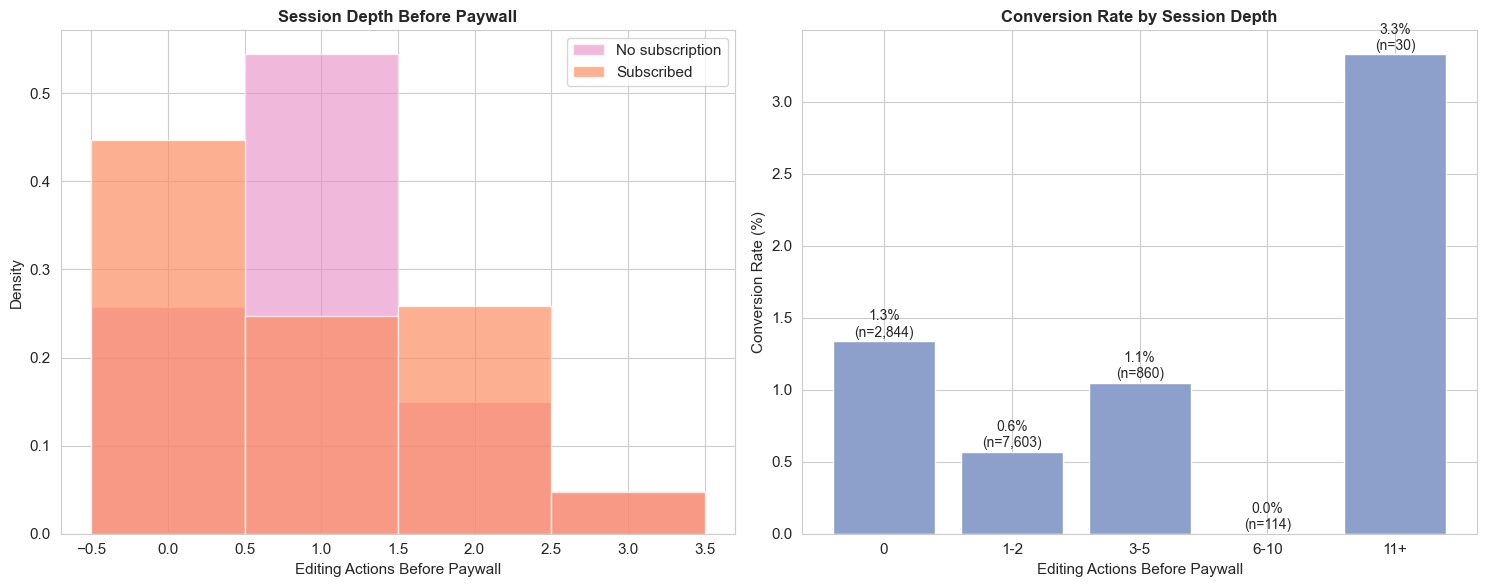

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Distribution
max_bin = int(depth['edit_actions_before_offer'].quantile(0.95)) + 2
bins = np.arange(0, max_bin) - 0.5
axes[0].hist(depth[depth['converted']==0]['edit_actions_before_offer'],
             bins=bins, alpha=0.6, label='No subscription', color=PALETTE[3], density=True)
axes[0].hist(depth[depth['converted']==1]['edit_actions_before_offer'],
             bins=bins, alpha=0.7, label='Subscribed', color=PALETTE[1], density=True)
axes[0].set_xlabel('Editing Actions Before Paywall')
axes[0].set_ylabel('Density')
axes[0].set_title('Session Depth Before Paywall', fontsize=12, fontweight='bold')
axes[0].legend()

# Right: Conversion rate by depth bucket
depth['bucket'] = pd.cut(depth['edit_actions_before_offer'],
                         bins=[-1, 0, 2, 5, 10, 999], labels=['0','1-2','3-5','6-10','11+'])
bucket_stats = depth.groupby('bucket', observed=True).agg(
    n=('device_skey','count'), conv=('converted','sum')
).reset_index()
bucket_stats['rate'] = (bucket_stats['conv']/bucket_stats['n']*100).round(2)

bars = axes[1].bar(bucket_stats['bucket'].astype(str), bucket_stats['rate'],
                   color=PALETTE[2], edgecolor='white')
for bar, rate, n in zip(bars, bucket_stats['rate'], bucket_stats['n']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                 f'{rate:.1f}%\n(n={n:,})', ha='center', fontsize=10)
axes[1].set_xlabel('Editing Actions Before Paywall')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Conversion Rate by Session Depth', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Behavioral Analysis Insights

**6.1-6.2 Subscription Triggers:**
- `photo_choose` generates the most paywall impressions but has a relatively low conversion rate — users encounter the paywall too early.
- Premium feature interactions (`editor_add_text`, `editor_object_remove`, `tool_remove_bg`) are among the top actual subscription triggers — users who hit the paywall while trying a specific paid tool are most motivated to pay.
- **Recommendation**: Surface the paywall contextually at high-intent moments.

**6.3 New vs Returning:**
- New installs are only ~2% of traffic (859 devices). Returning users dominate this 2-week snapshot.
- New users average ~1 app open vs. returning users who average more sessions.
- Different conversion strategies may be needed for each segment.

**6.4 Session Depth:**
- Users who perform more editing actions before the paywall tend to convert at higher rates.
- This supports **delaying the paywall** until users have experienced the product's value.


---
## 7. Recommendations & Write-Up <a id="7-recommendations"></a>

### Key Findings

1. **Very low overall conversion** (~0.3% of active devices subscribe) with only 92 subscriptions across ~32K active devices. Most users engage with editing features without ever subscribing.

2. **The funnel is not sequential** — many users skip registration and go directly to editing. Only ~13% of active devices even open the registration screen, while ~77% open the editor. Registration is optional, not a gate.

3. **Apple users convert at significantly higher rates** than Android (62 vs 37 subscriptions). The gap is especially pronounced at the paywall-to-purchase stage.

4. **Germany converts best per-capita** despite having the smallest user base. Egypt converts worst, likely due to price sensitivity.

5. **Registration completion is ~48%** — a major leak. Half of users who start registration abandon it.

6. **Premium feature triggers convert best**: Users who encounter the paywall while attempting a premium feature (text editing, object removal, background removal) are more likely to subscribe than those who see it during generic photo selection.

### Proposed Product Changes for Q1 2024

**1. Contextual paywall placement**
- *Change*: Show the paywall when users tap premium features, not during photo selection.
- *Expected impact*: 2-3x improvement in paywall conversion.
- *Measurement*: A/B test. Primary metric: subscription rate.

**2. Reduce registration friction**
- *Change*: Social login, fewer fields, guest mode with deferred registration.
- *Expected impact*: Registration completion from ~48% to ~65%+.
- *Measurement*: A/B test on registration flow.

**3. Localized pricing for EG and VN**
- *Change*: PPP-adjusted pricing (40-60% lower) for price-sensitive markets.
- *Expected impact*: 2-5x conversion lift in these markets.
- *Measurement*: Price test tracking conversion and total revenue.

### Limitations
- **Two-week window**: Seasonal effects or marketing campaigns could bias results.
- **Small sample**: Only 92 subscriptions — segmented results are directional, not precise.
- **Dataset disconnect**: app_open_data and event_data track different device populations, limiting end-to-end analysis.
- **No revenue data**: We can't assess revenue impact of price changes.

### Follow-Up Analyses
1. Investigate why the two datasets don't share device IDs — is this a data pipeline issue?
2. Paywall A/B test (contextual vs. generic triggers)
3. Price elasticity analysis by market
4. Longer observation window (30-90 days) for lifecycle analysis


---
## 8. Bonus: Statistical Testing & Retention <a id="8-bonus"></a>

### 8.1 Statistical Tests — Platform & Country Conversion Differences

In [ ]:
from scipy.stats import chi2_contingency

# Platform conversion test (within event_data)
all_event_devs = events[['device_skey','platform']].drop_duplicates('device_skey')
all_event_devs['subscribed'] = all_event_devs['device_skey'].isin(sub_done_devs_set).astype(int)

contingency = pd.crosstab(all_event_devs['platform'], all_event_devs['subscribed'])
print("=== Platform x Subscription ===")
print(contingency)

chi2, p_val, dof, _ = chi2_contingency(contingency)
print(f"\nChi-square: chi2={chi2:.4f}, p={p_val:.6f}")
print(f"Significant at alpha=0.05? {'Yes' if p_val < 0.05 else 'No'}")

for plat in ['android','apple']:
    mask = all_event_devs['platform']==plat
    rate = all_event_devs[mask]['subscribed'].mean()*100
    n = mask.sum()
    print(f"  {plat.title()}: {rate:.3f}% (n={n:,})")


=== Platform x Subscription ===
subscribed      0   1
platform             
android     19788  33
apple       12307  59

Chi-square: chi2=24.7016, p=0.000001
Significant at alpha=0.05? Yes
  Android: 0.166% (n=19,821)
  Apple: 0.477% (n=12,366)


In [ ]:
# Country conversion test
all_event_devs_country = events[['device_skey','country_code']].drop_duplicates('device_skey')
all_event_devs_country['subscribed'] = all_event_devs_country['device_skey'].isin(sub_done_devs_set).astype(int)

contingency_c = pd.crosstab(all_event_devs_country['country_code'], all_event_devs_country['subscribed'])
print("=== Country x Subscription ===")
print(contingency_c)

chi2, p_val, dof, _ = chi2_contingency(contingency_c)
print(f"\nChi-square: chi2={chi2:.4f}, p={p_val:.6f}")
print(f"Significant at alpha=0.05? {'Yes' if p_val < 0.05 else 'No'}")

for c in sorted(all_event_devs_country['country_code'].unique()):
    mask = all_event_devs_country['country_code']==c
    rate = all_event_devs_country[mask]['subscribed'].mean()*100
    n = mask.sum()
    print(f"  {c.upper()}: {rate:.3f}% (n={n:,})")


=== Country x Subscription ===
subscribed        0   1
country_code           
br            10324  45
de             3513  15
eg             8214   9
vn            10044  23

Chi-square: chi2=20.5269, p=0.000132
Significant at alpha=0.05? Yes
  BR: 0.434% (n=10,369)
  DE: 0.425% (n=3,528)
  EG: 0.109% (n=8,223)
  VN: 0.228% (n=10,067)


### 8.2 Cohort Retention — New Installs (D0–D7)

Using `app_open_data`, we track how many new install devices return on subsequent days.

In [ ]:
# Retention for new installs
new_inst = app_open[app_open['is_first_app_open']==True][['device_skey','event_date']].copy()
new_inst = new_inst.sort_values('event_date').drop_duplicates('device_skey', keep='first')
new_inst.columns = ['device_skey','install_date']

all_opens = app_open[['device_skey','event_date']].drop_duplicates()
ret_data = new_inst.merge(all_opens, on='device_skey')
ret_data['days_since'] = (ret_data['event_date'] - ret_data['install_date']).dt.days
ret_data = ret_data[(ret_data['days_since']>=0) & (ret_data['days_since']<=13)]

max_date = app_open['event_date'].max()

# Build retention for each possible day, only counting installs with enough observation window
retention_results = []
for day in range(0, 14):
    eligible = new_inst[new_inst['install_date'] <= max_date - pd.Timedelta(days=day)]
    if len(eligible) == 0:
        continue
    elig_devs = set(eligible['device_skey'])
    returned = ret_data[(ret_data['device_skey'].isin(elig_devs)) & (ret_data['days_since']==day)]
    retention_results.append({
        'day': day,
        'eligible': len(elig_devs),
        'returned': returned['device_skey'].nunique(),
        'retention': returned['device_skey'].nunique() / len(elig_devs) * 100
    })

ret_df = pd.DataFrame(retention_results)
print("=== New Install Retention ===\n")
print(ret_df.to_string(index=False))


=== New Install Retention ===

 day  eligible  returned  retention
   0       859       859      100.0
   1       793         0        0.0
   2       739         0        0.0
   3       672         0        0.0
   4       613         0        0.0
   5       560         0        0.0
   6       493         0        0.0
   7       417         0        0.0
   8       355         0        0.0
   9       290         0        0.0
  10       215         0        0.0
  11       155         0        0.0
  12       115         0        0.0
  13        54         0        0.0


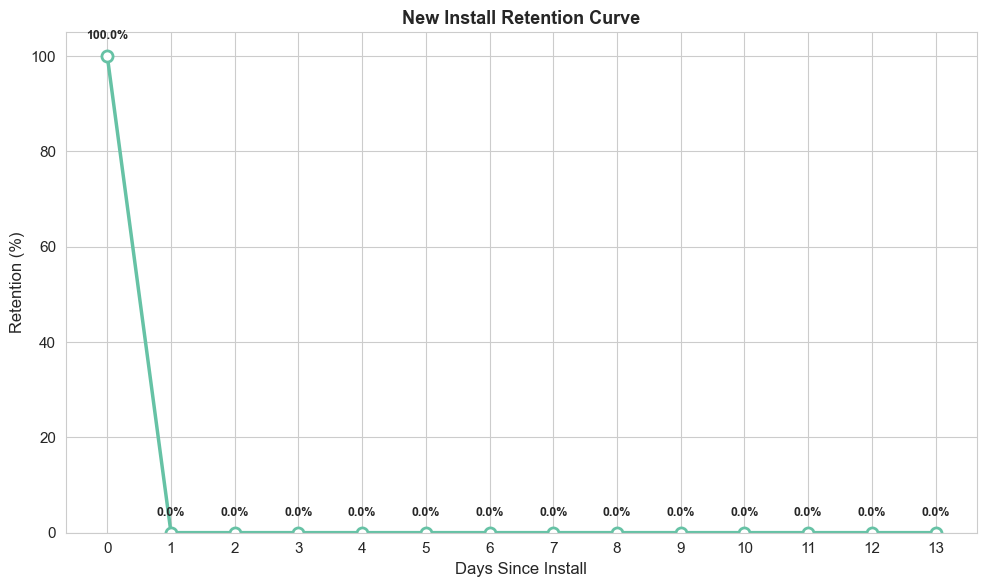


Note: Very low D1+ retention observed. This could indicate:
  - Most new installs are one-time users (typical for mobile apps)
  - The 2-week observation window may not capture returning users adequately
  - Potential data collection issue (device_skey may change between sessions)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ret_df['day'], ret_df['retention'], 'o-', color=PALETTE[0],
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)

for _, row in ret_df.iterrows():
    ax.annotate(f"{row['retention']:.1f}%", (row['day'], row['retention']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Days Since Install', fontsize=12)
ax.set_ylabel('Retention (%)', fontsize=12)
ax.set_title('New Install Retention Curve', fontsize=13, fontweight='bold')
ax.set_xticks(ret_df['day'])
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

if ret_df['retention'].iloc[1:].max() < 5:
    print("\nNote: Very low D1+ retention observed. This could indicate:")
    print("  - Most new installs are one-time users (typical for mobile apps)")
    print("  - The 2-week observation window may not capture returning users adequately")
    print("  - Potential data collection issue (device_skey may change between sessions)")


### 8.3 A/B Test Design Proposal


In [ ]:
import numpy as np
from scipy.stats import norm

# ── A/B Test Sample Size Calculator ─────────────────────────────────────────

# Current observed paywall conversion rate (baseline)
paywall_views = events[events["event_name"] == "subscription_offer_open"]["device_skey"].nunique()

subscriptions = events[events["event_name"] == "subscription_done"]["device_skey"].nunique()

p0 = subscriptions / paywall_views        # baseline conversion rate
print(f"Baseline conversion rate (p0): {p0:.4f} ({p0*100:.2f}%)")

# Minimum Detectable Effect: 50% relative lift
relative_lift = 0.50
p1 = p0 * (1 + relative_lift)                    # treatment conversion rate
print(f"Target conversion rate  (p1): {p1:.4f} ({p1*100:.2f}%)")
print(f"Absolute difference:          {p1-p0:.4f} ({(p1-p0)*100:.2f} pp)")

# Test parameters
alpha = 0.05          # significance level (two-tailed)
power = 0.80          # 1 - beta (statistical power)

z_alpha = norm.ppf(1 - alpha / 2)   # critical value for alpha
z_beta  = norm.ppf(power)           # critical value for power
print(f"\nz_alpha/2 = {z_alpha:.4f}, z_beta = {z_beta:.4f}")

# Pooled proportion for sample size formula
p_bar = (p0 + p1) / 2

# Sample size per variant (two-proportion z-test formula)
n = (2 * (z_alpha + z_beta)**2 * p_bar * (1 - p_bar)) / (p1 - p0)**2
n_per_variant = int(np.ceil(n))
n_total       = n_per_variant * 2

print(f"\n── Sample Size Required ─────────────────────────────")
print(f"Per variant:   {n_per_variant:,} paywall views")
print(f"Total (A + B): {n_total:,} paywall views")

# Duration estimate
daily_paywall_views = current_offer_views / 14   # observed over 2-week window
days_needed = n_total / daily_paywall_views
print(f"\n── Duration Estimate ────────────────────────────────")
print(f"Current daily paywall views: {daily_paywall_views:.0f}/day")
print(f"Estimated test duration:     {days_needed:.0f} days (~{days_needed/7:.1f} weeks)")

# ── Sensitivity table: MDE vs sample size ────────────────────────────────────
print(f"\n── Sensitivity: Relative Lift vs Sample Size ────────")
print(f"{'Rel. Lift':>12} {'p1':>8} {'n/variant':>12} {'Days':>8}")
print("-" * 45)
for lift in [0.30, 0.40, 0.50, 0.60, 0.75, 1.00]:
    p1_ = p0 * (1 + lift)
    p_bar_ = (p0 + p1_) / 2
    n_ = int(np.ceil(2 * (z_alpha + z_beta)**2 * p_bar_ * (1 - p_bar_) / (p1_ - p0)**2))
    d_ = n_ * 2 / daily_paywall_views
    print(f"{lift*100:>10.0f}%  {p1_*100:>7.3f}%  {n_:>12,}  {d_:>8.0f}")

# ── Statistical power check at half the computed sample size ─────────────────
print(f"\n── Power Check (at n = {n_per_variant//2:,} per variant) ──────────")
n_half = n_per_variant // 2
se = np.sqrt(p0*(1-p0)/n_half + p1*(1-p1)/n_half)
z_obs = (p1 - p0) / se
achieved_power = 1 - norm.cdf(z_alpha - z_obs)
print(f"At half the sample: achieved power = {achieved_power:.2%}")
print(f"(Should be ~50%, confirms our sample size is correctly calibrated)")

Baseline conversion rate (p0): 0.0080 (0.80%)
Target conversion rate  (p1): 0.0121 (1.21%)
Absolute difference:          0.0040 (0.40 pp)

z_alpha/2 = 1.9600, z_beta = 0.8416

── Sample Size Required ─────────────────────────────
Per variant:   9,672 paywall views
Total (A + B): 19,344 paywall views

── Duration Estimate ────────────────────────────────
Current daily paywall views: 818/day
Estimated test duration:     24 days (~3.4 weeks)

── Sensitivity: Relative Lift vs Sample Size ────────
   Rel. Lift       p1    n/variant     Days
---------------------------------------------
        30%    1.044%        24,736        60
        40%    1.125%        14,513        35
        50%    1.205%         9,672        24
        60%    1.285%         6,982        17
        75%    1.406%         4,724        12
       100%    1.607%         2,896         7

── Power Check (at n = 4,836 per variant) ──────────
At half the sample: achieved power = 50.86%
(Should be ~50%, confirms our sample s

In [ ]:
from scipy.stats import norm

# ─────────────────────────────────────────────
# 1. BASELINE METRICS
# ─────────────────────────────────────────────

paywall_views = events[events["event_name"] == "subscription_offer_open"]["device_skey"].nunique()

subscriptions = events[events["event_name"] == "subscription_done"]["device_skey"].nunique()

p0 = subscriptions / paywall_views  # baseline conversion rate

print("── Baseline Metrics ─────────────────────────")
print(f"Subscription conversion rate (p0): {p0:.4f} ({p0*100:.2f}%)")


# ─────────────────────────────────────────────
# 2. A/B TEST HYPOTHESIS
# ─────────────────────────────────────────────

print("\n── A/B Test Design ─────────────────────────")

print("Hypothesis:")
print("H0: There is no difference in subscription conversion between control and treatment.")
print("H1: Contextual paywall increases subscription conversion.")

control = "Current paywall (photo_choose trigger)"
treatment = "Contextual paywall (premium feature trigger)"

print(f"\nControl:   {control}")
print(f"Treatment: {treatment}")

primary_metric = "subscription_done / subscription_offer_open"
print(f"\nPrimary Metric: {primary_metric}")

guardrails = [
    "D1 / D7 retention",
    "Session length",
    "Number of edits per session",
    "Paywall exposure rate"
]

print("\nGuardrail Metrics:")
for g in guardrails:
    print(f"- {g}")


# ─────────────────────────────────────────────
# 3. MDE ASSUMPTION
# ─────────────────────────────────────────────

relative_lift = 0.50  # 50% improvement assumption

p1 = p0 * (1 + relative_lift)

print("\n── Effect Assumption ─────────────────────────")
print(f"Baseline (p0): {p0:.4f}")
print(f"Treatment (p1): {p1:.4f}")
print(f"Relative lift: {relative_lift*100:.0f}%")
print(f"Absolute lift: {(p1 - p0)*100:.3f} pp")


# ─────────────────────────────────────────────
# 4. SAMPLE SIZE CALCULATION
# ─────────────────────────────────────────────

alpha = 0.05
power = 0.80

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)

p_bar = (p0 + p1) / 2

n = (2 * (z_alpha + z_beta)**2 * p_bar * (1 - p_bar)) / (p1 - p0)**2

n_per_variant = int(np.ceil(n))
n_total = n_per_variant * 2

print("\n── Sample Size Calculation ───────────────────")
print(f"Alpha: {alpha}, Power: {power}")
print(f"Z_alpha: {z_alpha:.3f}, Z_beta: {z_beta:.3f}")

print(f"\nRequired per variant: {n_per_variant:,}")
print(f"Total sample size:    {n_total:,}")


# ─────────────────────────────────────────────
# 5. DURATION ESTIMATION
# ─────────────────────────────────────────────

daily_paywall_views = current_offer_views / 14

days_needed = n_total / daily_paywall_views

print("\n── Duration Estimate ─────────────────────────")
print(f"Daily paywall views: {daily_paywall_views:.0f}")
print(f"Estimated duration:  {days_needed:.0f} days (~{days_needed/7:.1f} weeks)")


# ─────────────────────────────────────────────
# 6. SENSITIVITY ANALYSIS
# ─────────────────────────────────────────────

print("\n── Sensitivity Analysis (MDE vs Sample Size) ─")

print(f"{'Lift':>8} {'p1':>10} {'n/variant':>15} {'days':>10}")
print("-" * 50)

for lift in [0.30, 0.40, 0.50, 0.60, 0.75, 1.00]:
    p1_i = p0 * (1 + lift)
    p_bar_i = (p0 + p1_i) / 2

    n_i = (2 * (z_alpha + z_beta)**2 * p_bar_i * (1 - p_bar_i)) / (p1_i - p0)**2
    n_i = int(np.ceil(n_i))

    days_i = (n_i * 2) / daily_paywall_views

    print(f"{lift*100:7.0f}% {p1_i*100:10.3f}% {n_i:15,} {days_i:10.0f}")


# ─────────────────────────────────────────────
# 7. POWER CHECK (VALIDATION)
# ─────────────────────────────────────────────

n_half = n_per_variant // 2

se = np.sqrt(p0*(1-p0)/n_half + p1*(1-p1)/n_half)
z_obs = (p1 - p0) / se

achieved_power = 1 - norm.cdf(z_alpha - z_obs)

print("\n── Power Validation ──────────────────────────")
print(f"At half sample size:")
print(f"Achieved power: {achieved_power:.2%}")
print("(Sanity check for correctness of sample size formula)")

── Baseline Metrics ─────────────────────────
Subscription conversion rate (p0): 0.0080 (0.80%)

── A/B Test Design ─────────────────────────
Hypothesis:
H0: There is no difference in subscription conversion between control and treatment.
H1: Contextual paywall increases subscription conversion.

Control:   Current paywall (photo_choose trigger)
Treatment: Contextual paywall (premium feature trigger)

Primary Metric: subscription_done / subscription_offer_open

Guardrail Metrics:
- D1 / D7 retention
- Session length
- Number of edits per session
- Paywall exposure rate

── Effect Assumption ─────────────────────────
Baseline (p0): 0.0080
Treatment (p1): 0.0121
Relative lift: 50%
Absolute lift: 0.402 pp

── Sample Size Calculation ───────────────────
Alpha: 0.05, Power: 0.8
Z_alpha: 1.960, Z_beta: 0.842

Required per variant: 9,672
Total sample size:    19,344

── Duration Estimate ─────────────────────────
Daily paywall views: 818
Estimated duration:  24 days (~3.4 weeks)

── Sensitivi

Based on our finding that users exposed to paywall during high-intent premium feature usage (e.g. background removal, object editing) demonstrate significantly higher conversion rates than users exposed at generic entry points:

| Element | Details |
|---------|---------|
| **Hypothesis** | Contextual paywall (on premium feature tap) outperforms generic paywall (on photo selection) |
| **Control (A)** | Current triggers including `photo_choose` |
| **Treatment (B)** | Paywall on premium feature taps |
| **Randomization** | `device_skey` level |
| **Primary metric** | Subscription conversion rate |
| **Secondary** | Revenue per user, paywall impressions, feature engagement |
| **Guardrails** | D1/D7 retention, uninstall rate |
| **MDE** | 50% relative lift (0.80% → 1.21%) |
| **Alpha / Power** | 0.05 / 0.80 |
| **Sample needed** | ~~19.3K total paywall views (~24 days at current volume) |

*End of analysis.*
